In [1]:
import os
import sys
import io
import contextlib

import numpy as np
import matplotlib.pyplot as plt


def find_project_root(start):
    """Walk upward from `start` to the nearest ancestor containing both greedy/ and core/."""
    d = os.path.abspath(start)
    for _ in range(6):
        if os.path.isdir(os.path.join(d, 'greedy')) and os.path.isdir(os.path.join(d, 'core')):
            return d
        d = os.path.dirname(d)
    raise RuntimeError('could not find a directory containing greedy/ and core/ above ' + start)


ROOT = find_project_root(os.getcwd())
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from greedy.greedy import greedy_trajectory
from plotting.heatmap_plot import plot_trajectory_density_grid
from core.cache import cached_run

CACHE_DIR = os.path.join(ROOT, '.cache', 'two_targets')

In [2]:
def run_trial(seed, gamma, A, src, N, K, T, sigma, stride, beta=1.0, r_stop=None, R_frac=0.20):
    """One greedy run for a single seed -> decimated, arrival-trimmed (x, y) points.

    Each cell's path is trimmed to its own first-arrival step (+ a short dwell
    buffer) so post-arrival equilibrium jitter doesn't dominate the density.

    `beta` is the kernel bandwidth (P_ij = exp(-beta * d^gamma)); beta=1 is the
    base model.
    """
    with contextlib.redirect_stdout(io.StringIO()):
        result = greedy_trajectory(src, A, gamma, N, K, T, mode='exp', log=True,
                                    sigma=sigma, seed=seed, r_stop=r_stop, beta=beta)
    traj = result['trajectory']                                     # (K+1, N, 2)

    arm_dist = np.linalg.norm(A[:, None] - A[None, :], axis=-1)
    R = R_frac * arm_dist[arm_dist > 0].mean()                       # "arrived" radius

    dist_to_A = np.linalg.norm(traj[:, :, None, :] - A[None, None, :, :], axis=-1)
    arrived = dist_to_A.min(axis=2) < R                              # (K+1, N)

    K1 = traj.shape[0]
    first_arrival = np.where(arrived.any(axis=0), arrived.argmax(axis=0), K1 - 1)
    dwell = max(1, int(0.03 * K1))
    cutoff = np.minimum(first_arrival + dwell, K1 - 1)
    keep = np.arange(K1)[:, None] <= cutoff[None, :]

    return traj[keep][::stride].astype(np.float32)

In [3]:
N, K, T, SIGMA = 70, 40000, 800.0, 0.005

A = np.array([[-1.0, 0.0], [1.0, 0.0]])   # archetypes at +-1.0 (matches the a_{1,2}=(-+1,0) geometry of the .tex)
SRC = np.array([0.0, -1.3])               # source depth 1.5 below the archetype axis

GAMMAS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
BETA = 1.6         # kernel bandwidth: P_ij = exp(-BETA * d^gamma). BETA=1 -> base model.
N_SEEDS = 30
STRIDE = 20

CMAP = 'viridis'
GAMMA_POW = 0.45   # PowerNorm exponent: boosts faint single-path trails
BINS = 220

In [4]:
# run the trial for each gamma, cached separately per (geometry, gamma, beta) so
# changing one gamma, the geometry, or the bandwidth only recomputes what changed
def _run_gamma(gamma):
    def _compute():
        arr = np.concatenate(
            [run_trial(seed, gamma, A, SRC, N, K, T, SIGMA, STRIDE, beta=BETA) for seed in range(N_SEEDS)],
            axis=0,
        )
        print(f'gamma={gamma}, beta={BETA}: {arr.shape[0]} points from {N_SEEDS} seeds')
        return arr

    gamma_params = dict(N=N, K=K, T=T, SIGMA=SIGMA, STRIDE=STRIDE, N_SEEDS=N_SEEDS, gamma=gamma,
                         beta=BETA, A=A.tolist(), SRC=SRC.tolist())
    return cached_run(CACHE_DIR, 'pts_gamma', gamma_params, _compute)


pts_by_gamma = {gamma: _run_gamma(gamma) for gamma in GAMMAS}

gamma=0.5, beta=1.6: 1144552 points from 30 seeds
[cache] saved pts_gamma to C:\Users\ASUS\PycharmProjects\dynamic_pareto\.cache\two_targets\pts_gamma_7c761322bd.pkl
gamma=1.0, beta=1.6: 579074 points from 30 seeds
[cache] saved pts_gamma to C:\Users\ASUS\PycharmProjects\dynamic_pareto\.cache\two_targets\pts_gamma_60cc4f7efd.pkl
gamma=1.5, beta=1.6: 389357 points from 30 seeds
[cache] saved pts_gamma to C:\Users\ASUS\PycharmProjects\dynamic_pareto\.cache\two_targets\pts_gamma_388d159b59.pkl
gamma=2.0, beta=1.6: 300420 points from 30 seeds
[cache] saved pts_gamma to C:\Users\ASUS\PycharmProjects\dynamic_pareto\.cache\two_targets\pts_gamma_f8b3223717.pkl
gamma=2.5, beta=1.6: 251644 points from 30 seeds
[cache] saved pts_gamma to C:\Users\ASUS\PycharmProjects\dynamic_pareto\.cache\two_targets\pts_gamma_8a8b7a7292.pkl
gamma=3.0, beta=1.6: 225115 points from 30 seeds
[cache] saved pts_gamma to C:\Users\ASUS\PycharmProjects\dynamic_pareto\.cache\two_targets\pts_gamma_9e67c44f3c.pkl
gamma=3.5

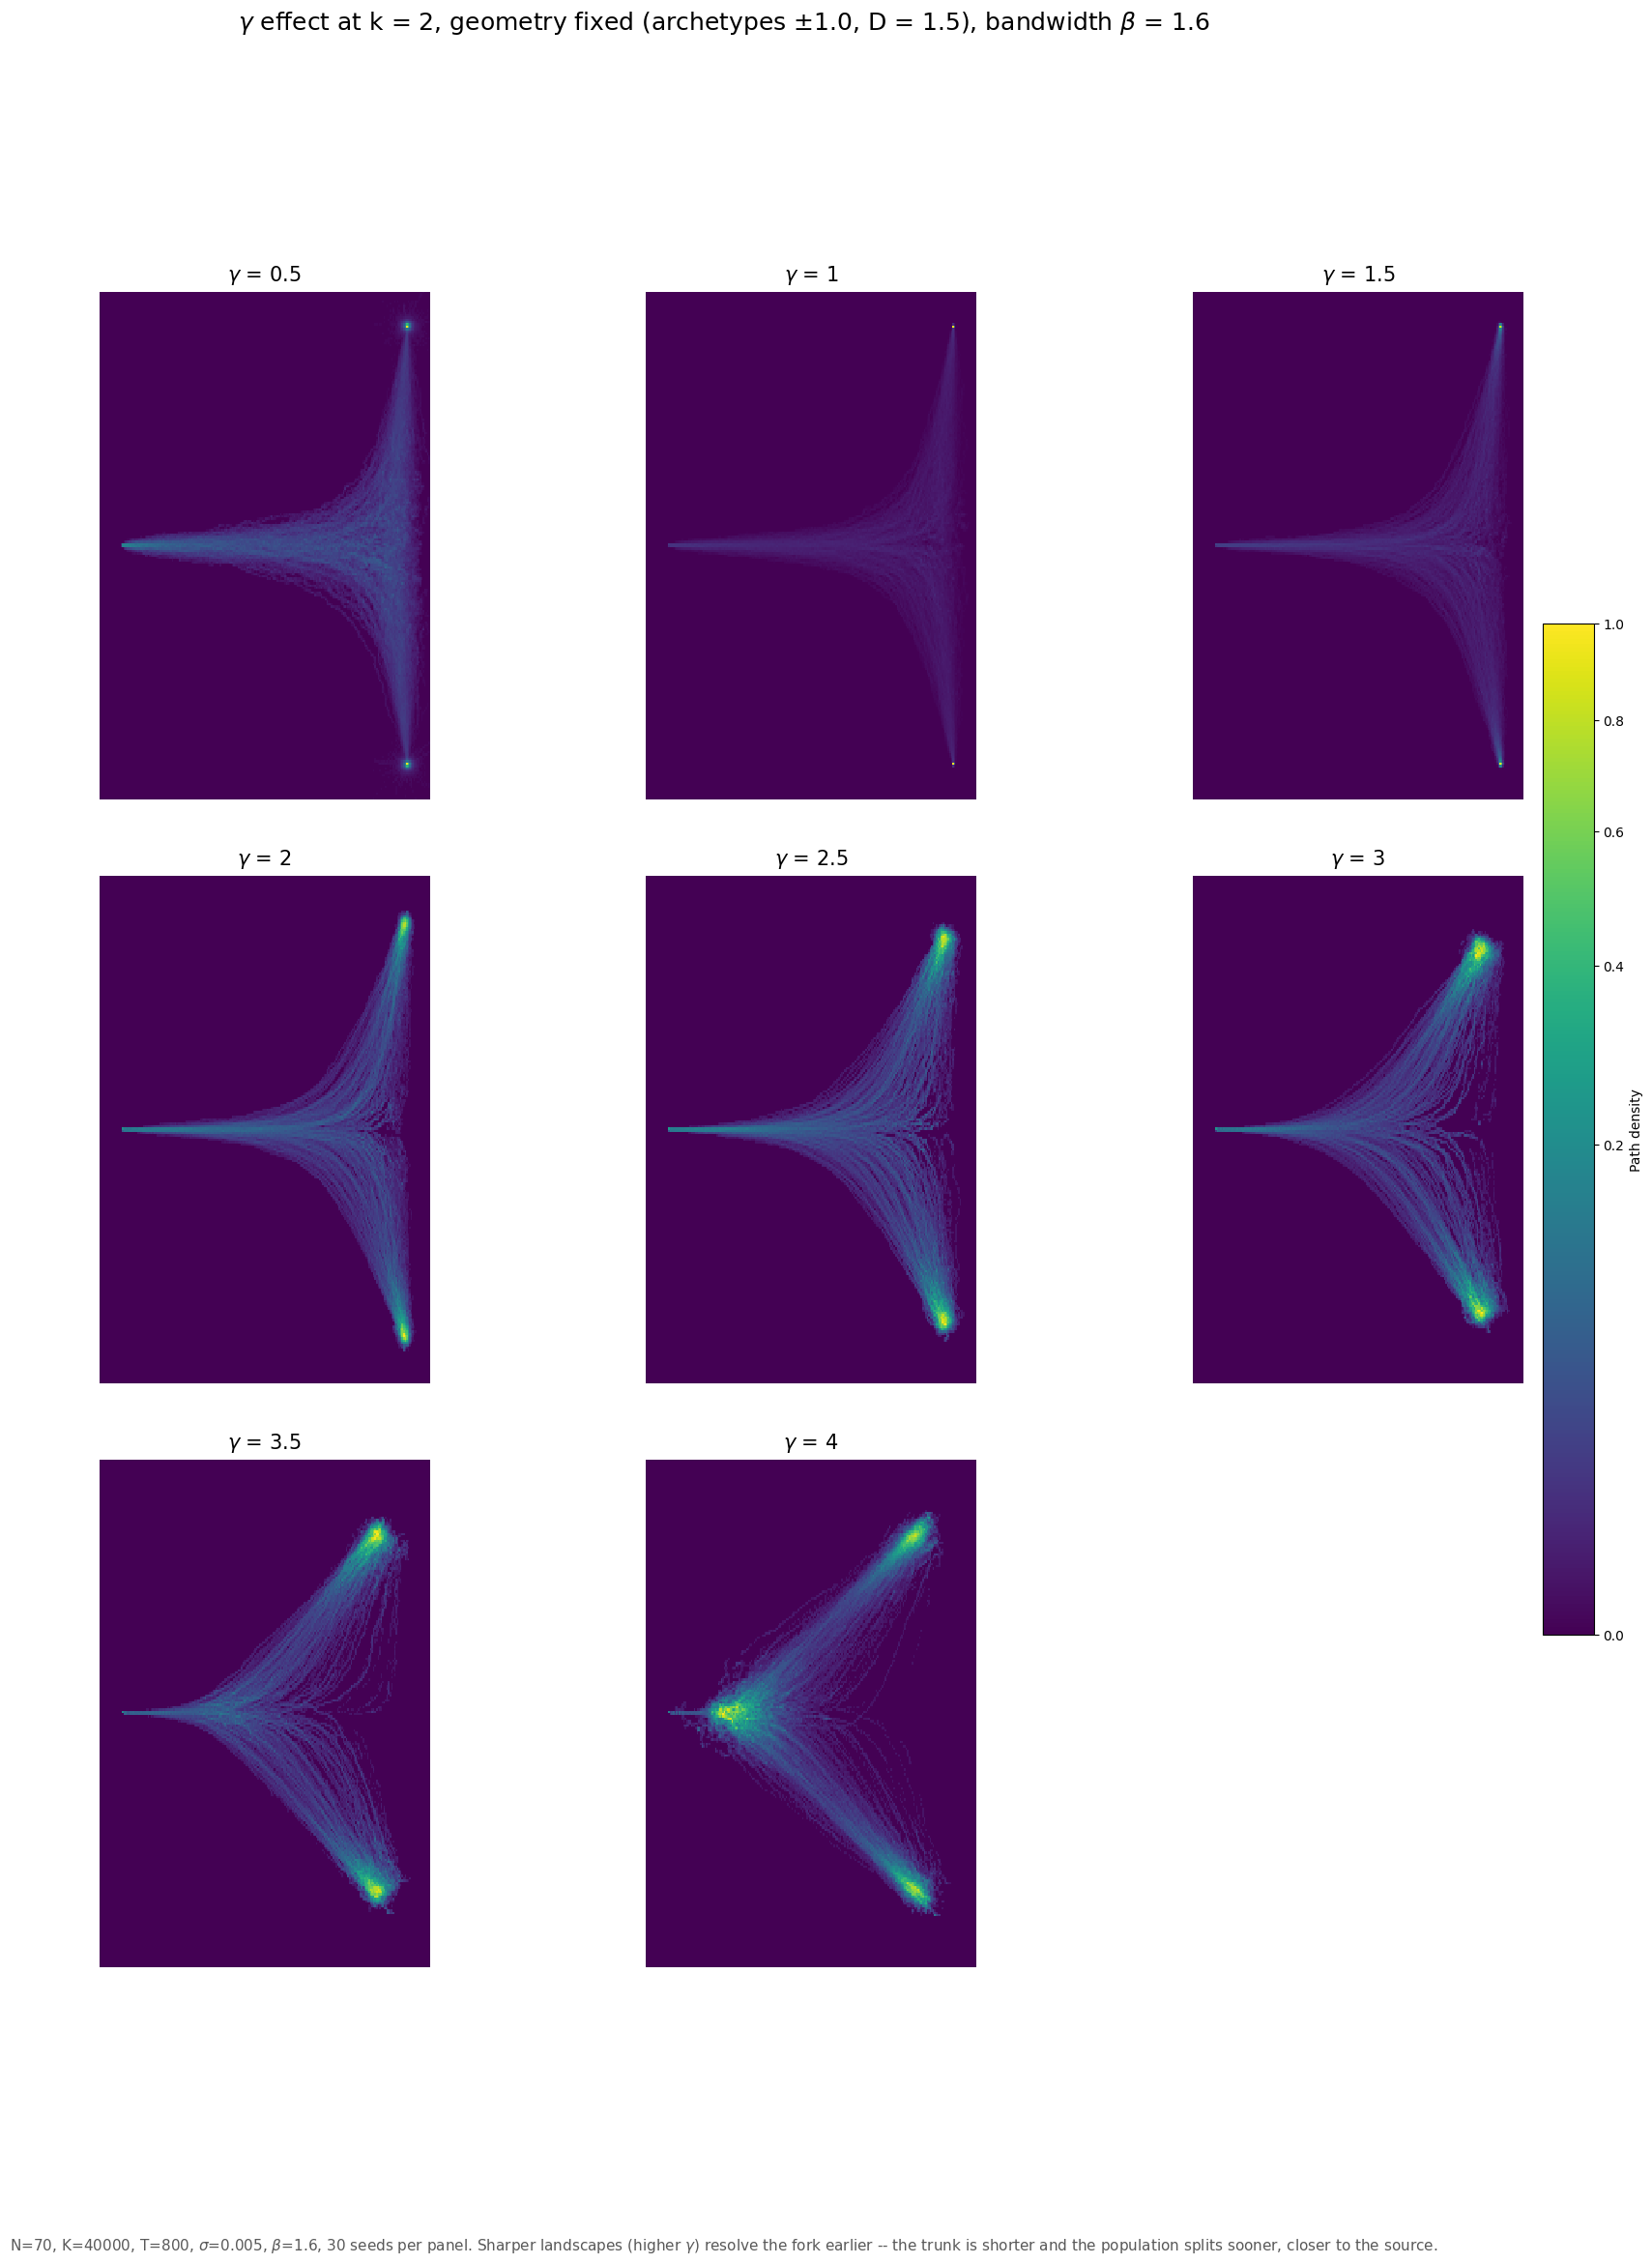

In [5]:
lim_points = [A, SRC[None, :]]

fig, axes = plot_trajectory_density_grid(
    pts_by_gamma, GAMMAS, [rf'$\gamma$ = {gamma:g}' for gamma in GAMMAS],
    lim_points=lim_points, bins=BINS, cmap=CMAP, gamma_pow=GAMMA_POW, pad=1.08,
    figsize_per_panel=(7.5, 7.5), ncols=3, minimal=True,
    suptitle=rf'$\gamma$ effect at k = 2, geometry fixed (archetypes $\pm$1.0, D = 1.5), bandwidth $\beta$ = {BETA:g}',
    caption=(f'N={N}, K={K}, T={T:g}, $\\sigma$={SIGMA}, $\\beta$={BETA:g}, {N_SEEDS} seeds per panel. Sharper '
             'landscapes (higher $\\gamma$) resolve the fork earlier -- '
             'the trunk is shorter and the population splits sooner, closer to the source.'),
    savefig='density_1_gamma_k2.png',
)
plt.show()